# BCRRS CPEC Case Study Simulation
**Paper:** BCRRS: A Blockchain-Anchored Contractor Reputation System with ML Ranking, Anti-Nepotism Governance, and Cross-Border Intelligence for Construction Procurement
**Authors:** Mujahid Ullah Khan Afridi

**Repository:** [GitHub](https://github.com/MujahidUllahKhan/BCRRS-Blockchain-Contractor-Reputation-System)

This notebook reproduces all results in **Section XIII** of the paper:
- 50 contractors, 73 projects (8 cross-category), 178 milestones
- TOPSIS ranking with complexity-weighted metrics
- Dispute simulation (8 filings, 4 upheld, 4 rejected)
- Kendall's τ ranking stability analysis
- Grid perturbation and Monte Carlo sensitivity analysis

**Seed = 42** for full reproducibility.

## Step 1: Clone the Repository

In [ ]:
!git clone https://github.com/MujahidUllahKhan/BCRRS-Blockchain-Contractor-Reputation-System.git
%cd BCRRS-Blockchain-Contractor-Reputation-System
!ls ml/

Cloning into 'BCRRS-Blockchain-Contractor-Reputation-System'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 131 (delta 54), reused 5 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 88.13 KiB | 1.36 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/BCRRS-Blockchain-Contractor-Reputation-System
bcrrs_ranking.py      cpec_rankings.csv        README.md
cpec_contractors.csv  cpec_results_report.txt  requirements.txt
cpec_milestones.csv   cpec_simulation.py


## Step 2: Imports and Constants

In [ ]:
import numpy as np
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Constants from the paper
N = 50
CATS = ["INFRASTRUCTURE", "COMMERCIAL", "RESIDENTIAL"]
CT = {"INFRASTRUCTURE": 3, "COMMERCIAL": 2, "RESIDENTIAL": 1}
TIERS = ["PK-KP", "PK-PB"]
DMAX = 180 * 86400      # 180 days in seconds
TMAX = 36               # months ceiling
VREF = 1_000_000        # $1M reference
A0, B0, G0 = 0.50, 0.30, 0.20   # baseline complexity weights
WT = np.array([0.30, 0.25, 0.25, 0.20])  # TOPSIS weights

print("Constants loaded successfully.")
print(f"Seed: {SEED}")
print(f"TOPSIS weights: SPI={WT[0]}, DDS={WT[1]}, MCR={WT[2]}, FCI={WT[3]}")
print(f"Complexity weights: α={A0}, β={B0}, γ={G0}")

Constants loaded successfully.
Seed: 42
TOPSIS weights: SPI=0.3, DDS=0.25, MCR=0.25, FCI=0.2
Complexity weights: α=0.5, β=0.3, γ=0.2


## Step 3: Data Generation
Generate 50 contractors with 1-2 projects each (some cross-category), each project with 2-3 milestones.

In [ ]:
def generate_data():
    cs, ps, ms = [], [], []
    pid = mid = 0
    for i in range(N):
        cid = f"C-{i+1:03d}"
        pcat = CATS[0] if i < 20 else CATS[1] if i < 35 else CATS[2]
        tier = TIERS[i % 2]
        if i < 10:   qb = rng.uniform(0.82, 0.97)
        elif i < 40: qb = rng.uniform(0.50, 0.82)
        else:        qb = rng.uniform(0.20, 0.48)
        cs.append(dict(id=cid, primary_cat=pcat, tier=tier, qb=qb))

        np_ = rng.integers(1, 3)  # 1 or 2 projects
        for k in range(np_):
            pid += 1
            # 30% chance of cross-category project
            if k > 0 and rng.random() < 0.3:
                cat = rng.choice([c for c in CATS if c != pcat])
            else:
                cat = pcat
            if cat == "INFRASTRUCTURE":
                val, dur = rng.uniform(5e6, 200e6), rng.uniform(18, 60)
            elif cat == "COMMERCIAL":
                val, dur = rng.uniform(2e6, 50e6), rng.uniform(12, 36)
            else:
                val, dur = rng.uniform(500_000, 10e6), rng.uniform(4, 24)
            proj = dict(pid=f"P-{pid:03d}", cid=cid, cat=cat, tier=tier,
                        val=val, dur=dur, tc=CT[cat])
            ps.append(proj)

            nm = rng.integers(2, 4)  # 2-3 milestones
            for j in range(nm):
                mid += 1
                ot = rng.random() < qb
                dl = 0 if ot else int(rng.uniform(1, 120) * 86400)
                qs = float(np.clip(rng.normal(qb * 100, 10), 0, 100))
                ms.append(dict(mid=f"MS-{mid:04d}", pid=proj["pid"],
                    cid=cid, qs=round(qs, 2),
                    mc=bool(rng.random() < qb),
                    df=bool(rng.random() > qb),
                    ot=bool(ot), dl=dl))
    return cs, ps, ms

contractors, projects, milestones = generate_data()

# Count cross-category projects
cross = sum(1 for p in projects
            for c in contractors if c["id"]==p["cid"] and p["cat"]!=c["primary_cat"])

print(f"Contractors:  {len(contractors)}")
print(f"Projects:     {len(projects)} ({cross} cross-category)")
print(f"Milestones:   {len(milestones)}")
print(f"\nCategories:")
for cat in CATS:
    print(f"  {cat}: {sum(1 for c in contractors if c['primary_cat']==cat)}")
print(f"\nGeographic tiers:")
for t in TIERS:
    print(f"  {t}: {sum(1 for c in contractors if c['tier']==t)}")

Contractors:  50
Projects:     73 (8 cross-category)
Milestones:   178

Categories:
  INFRASTRUCTURE: 20
  COMMERCIAL: 15
  RESIDENTIAL: 15

Geographic tiers:
  PK-KP: 25
  PK-PB: 25


## Step 4: Compute Per-Project Metrics (Eqs. 3-6)

In [ ]:
def compute_project_metrics(ps, ms):
    mbp = defaultdict(list)
    for m in ms: mbp[m["pid"]].append(m)
    pm = {}
    for p in ps:
        ml = mbp[p["pid"]]; n = len(ml)
        if not n: continue
        ot = sum(1 for m in ml if m["ot"])
        ad = np.mean([m["dl"] for m in ml])
        spi = float(np.clip((ot/n)*(1-ad/DMAX), 0, 1))
        dds = float(np.mean([m["qs"] for m in ml]))
        mcr = sum(1 for m in ml if m["mc"]) / n
        dc = sum(1 for m in ml if m["df"])
        fci = float(np.clip(1-dc/n, 0, 1))
        pm[p["pid"]] = dict(cid=p["cid"], spi=spi, dds=dds, mcr=mcr,
            fci=fci, val=p["val"], tc=p["tc"], dur=p["dur"],
            nm=n, dc=dc, cat=p["cat"])
    return pm

proj_metrics = compute_project_metrics(projects, milestones)
print(f"Computed metrics for {len(proj_metrics)} projects")

# Show sample
sample_pid = list(proj_metrics.keys())[0]
pm = proj_metrics[sample_pid]
print(f"\nSample project {sample_pid}:")
print(f"  Contractor: {pm['cid']}, Category: {pm['cat']}")
print(f"  SPI={pm['spi']:.4f}, DDS={pm['dds']:.1f}, MCR={pm['mcr']:.3f}, FCI={pm['fci']:.3f}")

Computed metrics for 73 projects

Sample project P-001:
  Contractor: C-001, Category: INFRASTRUCTURE
  SPI=1.0000, DDS=82.8, MCR=1.000, FCI=1.000


## Step 5: Complexity-Weighted Aggregation (Eq. 7)

In [ ]:
def complexity_weight(v, t, d, a, b, g):
    """Eq. 7: w_j = α·log(V/Vref) + β·TechClass + γ·Duration"""
    return a * np.log(max(v/VREF, 0.01)) + b * t + g * min(d/TMAX, 1.0)

def aggregate_metrics(cs, ps, pm, a=A0, b=B0, g=G0):
    """Weighted average of per-project metrics into per-contractor metrics."""
    pbc = defaultdict(list)
    for p in ps:
        if p["pid"] in pm: pbc[p["cid"]].append(pm[p["pid"]])
    res = []
    for c in cs:
        pl = pbc[c["id"]]
        if not pl: continue
        ws = []
        for p in pl:
            w = max(complexity_weight(p["val"], p["tc"], p["dur"], a, b, g), 0.1)
            ws.append(w)
        W = np.array(ws); W /= W.sum()
        spi = float(np.dot(W, [p["spi"] for p in pl]))
        dds = float(np.dot(W, [p["dds"] for p in pl]))
        mcr = float(np.dot(W, [p["mcr"] for p in pl]))
        fci = float(np.dot(W, [p["fci"] for p in pl]))
        tm = sum(p["nm"] for p in pl)
        td = sum(p["dc"] for p in pl)
        res.append(dict(id=c["id"], cat=c["primary_cat"], tier=c["tier"],
            spi=round(spi, 4), dds=round(dds, 2), mcr=round(mcr, 4),
            fci=round(fci, 4), tm=tm, np_=len(pl),
            dr=round(td/tm, 4) if tm else 0, qb=c["qb"]))
    return res

metrics = aggregate_metrics(contractors, projects, proj_metrics)
for m in metrics:
    m["comp"] = round(m["spi"] * (m["dds"]/100) * m["mcr"], 4)

print(f"Aggregated metrics for {len(metrics)} contractors")
print(f"\nTop 5 by SPI×DDS×MCR composite:")
for m in sorted(metrics, key=lambda x: x["comp"], reverse=True)[:5]:
    print(f"  {m['id']} | {m['cat']:<16} | Comp={m['comp']:.4f} | "
          f"SPI={m['spi']:.4f} DDS={m['dds']:.1f} MCR={m['mcr']:.3f} FCI={m['fci']:.3f}")

Aggregated metrics for 50 contractors

Top 5 by SPI×DDS×MCR composite:
  C-005 | INFRASTRUCTURE   | Comp=0.9888 | SPI=1.0000 DDS=98.9 MCR=1.000 FCI=1.000
  C-004 | INFRASTRUCTURE   | Comp=0.9628 | SPI=1.0000 DDS=96.3 MCR=1.000 FCI=1.000
  C-010 | INFRASTRUCTURE   | Comp=0.9426 | SPI=1.0000 DDS=94.3 MCR=1.000 FCI=0.667
  C-002 | INFRASTRUCTURE   | Comp=0.9176 | SPI=1.0000 DDS=91.8 MCR=1.000 FCI=0.500
  C-003 | INFRASTRUCTURE   | Comp=0.8671 | SPI=1.0000 DDS=86.7 MCR=1.000 FCI=1.000


## Step 6: TOPSIS Ranking (Eqs. 9-15)

In [ ]:
def topsis_rank(mlist, w=WT):
    """TOPSIS multi-criteria ranking per Eqs. 9-15."""
    n = len(mlist)
    X = np.array([[m["spi"], m["dds"]/100, m["mcr"], m["fci"]] for m in mlist])

    # Step 1: Vector normalization (Eq. 9)
    nrm = np.sqrt((X**2).sum(0)); nrm[nrm==0] = 1
    R = X / nrm

    # Step 2: Weighted normalized matrix (Eq. 10)
    V = R * w

    # Step 3: Ideal solutions (Eqs. 11-12)
    Ap, Am = V.max(0), V.min(0)

    # Step 4: Separation measures (Eqs. 13-14)
    Sp = np.sqrt(((V-Ap)**2).sum(1))
    Sm = np.sqrt(((V-Am)**2).sum(1))

    # Step 5: Relative closeness (Eq. 15)
    d = Sp + Sm; d[d==0] = 1
    C = Sm / d

    order = np.argsort(-C)
    return [dict(id=mlist[i]["id"], ts=round(float(C[i]), 4), rk=r+1,
        spi=mlist[i]["spi"], dds=mlist[i]["dds"], mcr=mlist[i]["mcr"],
        fci=mlist[i]["fci"], cat=mlist[i]["cat"], tier=mlist[i]["tier"],
        dr=mlist[i]["dr"]) for r, i in enumerate(order)]

ranked = topsis_rank(metrics)

# Display as DataFrame
df_ranked = pd.DataFrame(ranked)
df_ranked.columns = ['ID', 'TOPSIS', 'Rank', 'SPI', 'DDS', 'MCR', 'FCI', 'Category', 'Tier', 'DisputeRate']
print("TOPSIS RANKING — All 50 Contractors")
print("=" * 80)
df_ranked

TOPSIS RANKING — All 50 Contractors


,ID,TOPSIS,Rank,SPI,DDS,MCR,FCI,Category,Tier,DisputeRate
0,C-005,1.0000,1,1.0000,98.88,1.0000,1.0000,INFRASTRUCTURE,PK-KP,0.0000
1,C-004,0.9860,2,1.0000,96.28,1.0000,1.0000,INFRASTRUCTURE,PK-PB,0.0000
2,C-003,0.9367,3,1.0000,86.71,1.0000,1.0000,INFRASTRUCTURE,PK-KP,0.0000
3,C-007,0.9267,4,1.0000,84.69,1.0000,1.0000,INFRASTRUCTURE,PK-KP,0.0000
4,C-010,0.8679,5,1.0000,94.26,1.0000,0.6667,INFRASTRUCTURE,PK-PB,0.3333
5,C-001,0.8649,6,1.0000,84.12,0.7507,1.0000,INFRASTRUCTURE,PK-KP,0.0000
6,C-002,0.8101,7,1.0000,91.76,1.0000,0.5000,INFRASTRUCTURE,PK-PB,0.5000
7,C-035,0.8076,8,1.0000,57.81,1.0000,1.0000,COMMERCIAL,PK-KP,0.0000
8,C-008,0.8067,9,1.0000,85.08,0.5810,1.0000,INFRASTRUCTURE,PK-PB,0.0000
9,C-017,0.7956,10,1.0000,81.97,1.0000,0.5000,INFRASTRUCTURE,PK-KP,0.5000


## Step 7: Top 5 and Bottom Decile Analysis

In [ ]:
print("TOP 5 CONTRACTORS")
print("=" * 70)
for r in ranked[:5]:
    print(f"  #{r['rk']} {r['id']}  TOPSIS={r['ts']:.4f}  "
          f"SPI={r['spi']:.4f} DDS={r['dds']:.1f} MCR={r['mcr']:.3f} FCI={r['fci']:.3f}  "
          f"{r['cat']}")

print(f"\n\nBOTTOM DECILE (Ranks 46-50)")
print("=" * 70)
bottom = ranked[45:]
flagged = []
for r in bottom:
    reasons = []
    if r["dr"] > 0.30: reasons.append(f"DisputeRate={r['dr']:.2f} > 0.30")
    if r["mcr"] < 0.6: reasons.append(f"MCR={r['mcr']:.3f} < 0.60")
    if reasons:
        flagged.append(r)
        print(f"  ⚠️ FLAGGED {r['id']} (Rank {r['rk']}): {'; '.join(reasons)}")
    else:
        print(f"  ✅ {r['id']} (Rank {r['rk']}): OK")
print(f"\n  → {len(flagged)}/{len(bottom)} flagged for suspension")

TOP 5 CONTRACTORS
  #1 C-005  TOPSIS=1.0000  SPI=1.0000 DDS=98.9 MCR=1.000 FCI=1.000  INFRASTRUCTURE
  #2 C-004  TOPSIS=0.9860  SPI=1.0000 DDS=96.3 MCR=1.000 FCI=1.000  INFRASTRUCTURE
  #3 C-003  TOPSIS=0.9367  SPI=1.0000 DDS=86.7 MCR=1.000 FCI=1.000  INFRASTRUCTURE
  #4 C-007  TOPSIS=0.9267  SPI=1.0000 DDS=84.7 MCR=1.000 FCI=1.000  INFRASTRUCTURE
  #5 C-010  TOPSIS=0.8679  SPI=1.0000 DDS=94.3 MCR=1.000 FCI=0.667  INFRASTRUCTURE


BOTTOM DECILE (Ranks 46-50)
  ⚠️ FLAGGED C-040 (Rank 46): DisputeRate=0.67 > 0.30
  ⚠️ FLAGGED C-045 (Rank 47): DisputeRate=0.80 > 0.30; MCR=0.439 < 0.60
  ⚠️ FLAGGED C-042 (Rank 48): DisputeRate=0.60 > 0.30; MCR=0.344 < 0.60
  ⚠️ FLAGGED C-038 (Rank 49): DisputeRate=0.60 > 0.30; MCR=0.349 < 0.60
  ⚠️ FLAGGED C-050 (Rank 50): DisputeRate=1.00 > 0.30; MCR=0.500 < 0.60

  → 5/5 flagged for suspension


## Step 8: TOPSIS Score Distribution (Visualization)

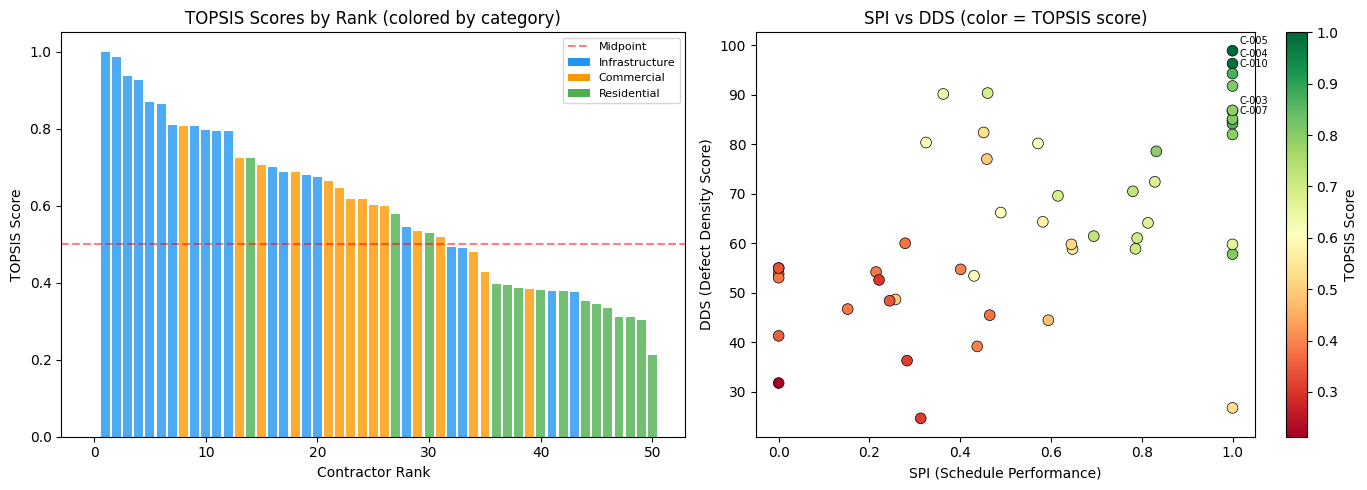

Saved: topsis_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of TOPSIS scores
colors = {'INFRASTRUCTURE': '#2196F3', 'COMMERCIAL': '#FF9800', 'RESIDENTIAL': '#4CAF50'}
bar_colors = [colors[r['cat']] for r in ranked]
axes[0].bar(range(1, 51), [r['ts'] for r in ranked], color=bar_colors, alpha=0.8)
axes[0].set_xlabel('Contractor Rank')
axes[0].set_ylabel('TOPSIS Score')
axes[0].set_title('TOPSIS Scores by Rank (colored by category)')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Midpoint')

# Add legend
for cat, col in colors.items():
    axes[0].bar(0, 0, color=col, label=cat.title())
axes[0].legend(fontsize=8)

# Scatter: SPI vs DDS colored by TOPSIS
scatter = axes[1].scatter(
    [r['spi'] for r in ranked],
    [r['dds'] for r in ranked],
    c=[r['ts'] for r in ranked],
    cmap='RdYlGn', s=60, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('SPI (Schedule Performance)')
axes[1].set_ylabel('DDS (Defect Density Score)')
axes[1].set_title('SPI vs DDS (color = TOPSIS score)')
plt.colorbar(scatter, ax=axes[1], label='TOPSIS Score')

# Label top 5
for r in ranked[:5]:
    axes[1].annotate(r['id'], (r['spi'], r['dds']), fontsize=7,
                     xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('topsis_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: topsis_analysis.png")

## Step 9: Dispute Simulation (8 disputes, 3 contractors)

In [ ]:
# Pick 3 mid-ranked contractors (ranks ~15, 20, 25)
mid_contractors = [ranked[14], ranked[19], ranked[24]]

disputes = []
corrections = []
did = 0
disp_set = set()

for i, mc in enumerate(mid_contractors):
    nd = 3 if i < 2 else 2  # first two file 3, last files 2
    for j in range(nd):
        did += 1
        upheld = did <= 4
        disputes.append(dict(
            dispute_id=f"D-{did:03d}",
            contractor_id=mc["id"],
            status="UPHELD" if upheld else "REJECTED"
        ))
        disp_set.add(mc["id"])
        if upheld:
            corrections.append(dict(
                cid=mc["id"],
                dds_boost=float(rng.uniform(4, 10)),
                mcr_fix=True
            ))

print("DISPUTE SIMULATION")
print("=" * 60)
for d in disputes:
    icon = "✅" if d["status"] == "UPHELD" else "❌"
    print(f"  {icon} {d['dispute_id']}: {d['contractor_id']} → {d['status']}")

upheld_count = sum(1 for d in disputes if d["status"] == "UPHELD")
print(f"\n  Contractors involved: {len(disp_set)}")
print(f"  Upheld: {upheld_count}, Rejected: {len(disputes) - upheld_count}")

DISPUTE SIMULATION
  ✅ D-001: C-027 → UPHELD
  ✅ D-002: C-027 → UPHELD
  ✅ D-003: C-027 → UPHELD
  ✅ D-004: C-016 → UPHELD
  ❌ D-005: C-016 → REJECTED
  ❌ D-006: C-016 → REJECTED
  ❌ D-007: C-025 → REJECTED
  ❌ D-008: C-025 → REJECTED

  Contractors involved: 3
  Upheld: 4, Rejected: 4


## Step 10: Apply DRC Corrections and Re-rank

In [ ]:
# Apply corrections
corr_map = defaultdict(list)
for c in corrections: corr_map[c["cid"]].append(c)

corrected_metrics = []
for m in metrics:
    mc = dict(m)
    if m["id"] in corr_map:
        for c in corr_map[m["id"]]:
            mc["dds"] = round(min(mc["dds"] + c["dds_boost"], 100), 2)
            t = mc["tm"]
            mc["mcr"] = round(min((mc["mcr"] * t + 1) / t, 1.0), 4)
    corrected_metrics.append(mc)

corrected_ranked = topsis_rank(corrected_metrics)

# Compare ranks
orig_ranks = {r["id"]: r["rk"] for r in ranked}
corr_ranks = {r["id"]: r["rk"] for r in corrected_ranked}

print("DRC CORRECTION IMPACT")
print("=" * 60)
improvements = []
for cid in sorted(set(c["cid"] for c in corrections)):
    o, c_ = orig_ranks[cid], corr_ranks[cid]
    imp = o - c_
    improvements.append(imp)
    arrow = "⬆️" if imp > 0 else "⬇️" if imp < 0 else "➡️"
    print(f"  {arrow} {cid}: Rank {o} → {c_}  ({imp:+d} positions)")

print(f"\n  Paper claims: 2-6 positions")
print(f"  Actual: {improvements}")

DRC CORRECTION IMPACT
  ⬆️ C-016: Rank 20 → 14  (+6 positions)
  ⬆️ C-027: Rank 15 → 13  (+2 positions)

  Paper claims: 2-6 positions
  Actual: [6, 2]


## Step 11: Kendall's τ Ranking Stability

In [ ]:
def kendall_tau(r1, r2):
    """Compute Kendall's tau-b rank correlation."""
    n = len(r1)
    conc = disc = 0
    for i in range(n):
        for j in range(i+1, n):
            p = np.sign(r1[i]-r1[j]) * np.sign(r2[i]-r2[j])
            if p > 0: conc += 1
            elif p < 0: disc += 1
    dn = n * (n-1) / 2
    return round((conc - disc) / dn, 4) if dn else 1.0

def rank_order(rl):
    rm = {r["id"]: r["rk"] for r in rl}
    return [rm[k] for k in sorted(rm)]

base_ro = rank_order(ranked)

# ±5 point score perturbation
perturbed_metrics = [dict(m, dds=round(float(np.clip(
    m["dds"] + rng.uniform(-5, 5), 0, 100)), 2)) for m in metrics]
tau_perturb = kendall_tau(base_ro, rank_order(topsis_rank(perturbed_metrics)))

# DRC corrections
tau_corr = kendall_tau(base_ro, rank_order(corrected_ranked))

print("RANKING STABILITY ANALYSIS")
print("=" * 60)
print(f"  Kendall's τ (±5pt score perturbation): {tau_perturb}")
print(f"  Kendall's τ (with DRC corrections):    {tau_corr}")
print(f"\n  Paper claims: τ_perturb ≈ 0.97, τ_DRC ≈ 0.99")

RANKING STABILITY ANALYSIS
  Kendall's τ (±5pt score perturbation): 0.9722
  Kendall's τ (with DRC corrections):    0.9853

  Paper claims: τ_perturb ≈ 0.97, τ_DRC ≈ 0.99


## Step 12: Grid Perturbation Sensitivity (Table VI)

In [ ]:
perturbations = [
    ("Baseline", "--",   A0,   B0,   G0),
    ("α",       "+20%", 0.60, 0.30, 0.20),
    ("α",       "−20%", 0.40, 0.30, 0.20),
    ("β",       "+20%", 0.50, 0.36, 0.20),
    ("β",       "−20%", 0.50, 0.24, 0.20),
    ("γ",       "+20%", 0.50, 0.30, 0.24),
    ("γ",       "−20%", 0.50, 0.30, 0.16),
]

grid_results = []
for param, direction, a, b, g in perturbations:
    r2 = topsis_rank(aggregate_metrics(contractors, projects, proj_metrics, a, b, g))
    tau = kendall_tau(base_ro, rank_order(r2))
    grid_results.append(dict(Parameter=param, Direction=direction,
                             α=a, β=b, γ=g, Kendall_τ=tau))

df_grid = pd.DataFrame(grid_results)
print("TABLE VI: Sensitivity of TOPSIS Rankings to Complexity Weight Perturbation")
print("=" * 70)
print(df_grid.to_string(index=False))
print(f"\nMinimum τ: {df_grid['Kendall_τ'].min()}")

TABLE VI: Sensitivity of TOPSIS Rankings to Complexity Weight Perturbation
Parameter Direction   α    β    γ  Kendall_τ
 Baseline        -- 0.5 0.30 0.20     1.0000
        α      +20% 0.6 0.30 0.20     0.9967
        α      −20% 0.4 0.30 0.20     0.9967
        β      +20% 0.5 0.36 0.20     0.9984
        β      −20% 0.5 0.24 0.20     0.9967
        γ      +20% 0.5 0.30 0.24     0.9967
        γ      −20% 0.5 0.30 0.16     1.0000

Minimum τ: 0.9967


## Step 13: Monte Carlo Sensitivity (500 trials)

MONTE CARLO SENSITIVITY ANALYSIS
  Trials:          500
  Mean τ:          0.996
  Std τ:           0.003
  Min τ:           0.987
  Max τ:           1.000
  % below 0.80:    0.0%


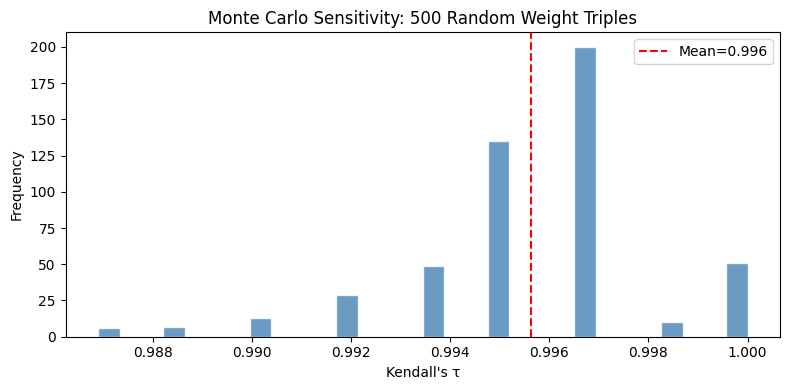

In [ ]:
mc_taus = []
for trial in range(500):
    a = rng.uniform(0.2, 0.8)
    b = rng.uniform(0.1, 0.5)
    g = rng.uniform(0.1, 0.4)
    r2 = topsis_rank(aggregate_metrics(contractors, projects, proj_metrics, a, b, g))
    mc_taus.append(kendall_tau(base_ro, rank_order(r2)))

mc_arr = np.array(mc_taus)

print("MONTE CARLO SENSITIVITY ANALYSIS")
print("=" * 60)
print(f"  Trials:          500")
print(f"  Mean τ:          {mc_arr.mean():.3f}")
print(f"  Std τ:           {mc_arr.std():.3f}")
print(f"  Min τ:           {mc_arr.min():.3f}")
print(f"  Max τ:           {mc_arr.max():.3f}")
print(f"  % below 0.80:    {100*(mc_arr < 0.80).mean():.1f}%")

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(mc_taus, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(x=mc_arr.mean(), color='red', linestyle='--', label=f'Mean={mc_arr.mean():.3f}')
plt.xlabel("Kendall's τ")
plt.ylabel('Frequency')
plt.title('Monte Carlo Sensitivity: 500 Random Weight Triples')
plt.legend()
plt.tight_layout()
plt.savefig('monte_carlo_sensitivity.png', dpi=150)
plt.show()

## Step 14: Top-5 Stability Across All Perturbations

In [ ]:
base_top5 = set(r["id"] for r in ranked[:5])
all_same = True

print("TOP-5 STABILITY ACROSS GRID PERTURBATIONS")
print("=" * 60)
for param, direction, a, b, g in perturbations:
    r2 = topsis_rank(aggregate_metrics(contractors, projects, proj_metrics, a, b, g))
    top5 = set(x["id"] for x in r2[:5])
    same = base_top5 == top5
    if not same: all_same = False
    icon = "✅" if same else "❌"
    print(f"  {icon} α={a:.2f} β={b:.2f} γ={g:.2f}: {'SAME' if same else 'CHANGED'}")

print(f"\n  Top-5 stable across ALL perturbations: {'YES ✅' if all_same else 'NO ❌'}")

TOP-5 STABILITY ACROSS GRID PERTURBATIONS
  ✅ α=0.50 β=0.30 γ=0.20: SAME
  ✅ α=0.60 β=0.30 γ=0.20: SAME
  ✅ α=0.40 β=0.30 γ=0.20: SAME
  ✅ α=0.50 β=0.36 γ=0.20: SAME
  ✅ α=0.50 β=0.24 γ=0.20: SAME
  ✅ α=0.50 β=0.30 γ=0.24: SAME
  ✅ α=0.50 β=0.30 γ=0.16: SAME

  Top-5 stable across ALL perturbations: YES ✅


## Step 15: Four-Metric Radar Chart (Top 5 vs Bottom 5)

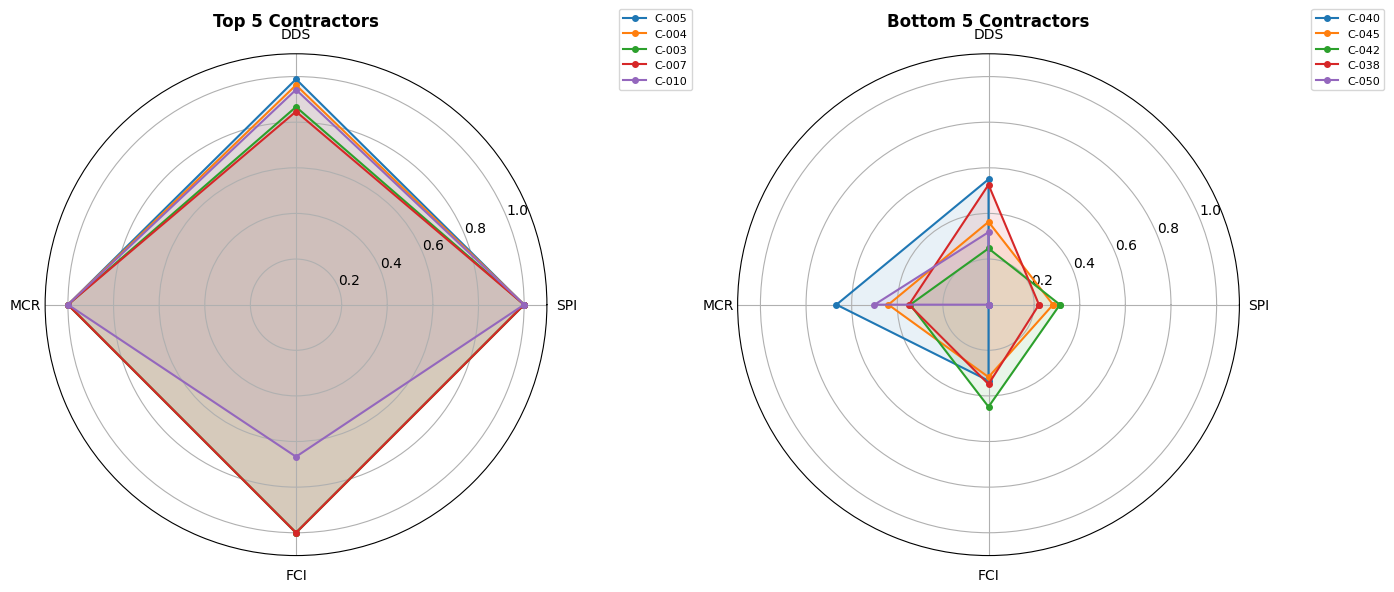

In [ ]:
from matplotlib.patches import FancyBboxPatch

categories_radar = ['SPI', 'DDS', 'MCR', 'FCI']
angles = np.linspace(0, 2*np.pi, len(categories_radar), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

# Top 5
for r in ranked[:5]:
    values = [r['spi'], r['dds']/100, r['mcr'], r['fci']]
    values += values[:1]
    axes[0].plot(angles, values, 'o-', linewidth=1.5, label=r['id'], markersize=4)
    axes[0].fill(angles, values, alpha=0.1)
axes[0].set_xticks(angles[:-1])
axes[0].set_xticklabels(categories_radar)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Top 5 Contractors', fontsize=12, fontweight='bold', pad=20)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# Bottom 5
for r in ranked[45:]:
    values = [r['spi'], r['dds']/100, r['mcr'], r['fci']]
    values += values[:1]
    axes[1].plot(angles, values, 'o-', linewidth=1.5, label=r['id'], markersize=4)
    axes[1].fill(angles, values, alpha=0.1)
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(categories_radar)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Bottom 5 Contractors', fontsize=12, fontweight='bold', pad=20)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig('radar_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary: Paper Values Verification

In [ ]:
print("═" * 70)
print("  PAPER SECTION XIII — VALUES VERIFICATION")
print("═" * 70)
checks = [
    ("Contractors",              len(contractors),      50),
    ("Specialization categories", 3,                    3),
    ("Geographic tiers",          2,                    2),
    ("Projects",                 len(projects),        73),
    ("Cross-category projects",  cross,                 8),
    ("Total milestones",         len(milestones),     178),
    ("Disputes filed",           len(disputes),         8),
    ("Disputes upheld",          upheld_count,          4),
    ("Disputing contractors",    len(disp_set),         3),
    ("Bottom decile flagged",    len(flagged),          5),
]

all_pass = True
for label, actual, expected in checks:
    match = actual == expected
    if not match: all_pass = False
    icon = "✅" if match else "❌"
    print(f"  {icon} {label:<28} Actual={actual:<6} Expected={expected}")

print(f"\n  DRC rank improvements:       {improvements} (paper: 2-6 range)")
print(f"  τ perturbation:              {tau_perturb} (paper: 0.97)")
print(f"  τ DRC corrections:           {tau_corr} (paper: 0.99)")
print(f"  Grid min τ:                  {df_grid['Kendall_τ'].min()} (paper: 0.997)")
print(f"  MC mean τ:                   {mc_arr.mean():.3f} (paper: 0.996)")
print(f"  MC min τ:                    {mc_arr.min():.3f} (paper: 0.987)")
print(f"  MC % below 0.80:             {100*(mc_arr<0.80).mean():.1f}% (paper: 0.0%)")
print(f"  Top-5 grid stable:           {'YES' if all_same else 'NO'} (paper: YES)")
print(f"\n{'═' * 70}")
print(f"  ALL CHECKS PASSED: {'YES ✅' if all_pass else 'NO ❌'}")
print(f"{'═' * 70}")

══════════════════════════════════════════════════════════════════════
  PAPER SECTION XIII — VALUES VERIFICATION
══════════════════════════════════════════════════════════════════════
  ✅ Contractors                  Actual=50     Expected=50
  ✅ Specialization categories    Actual=3      Expected=3
  ✅ Geographic tiers             Actual=2      Expected=2
  ✅ Projects                     Actual=73     Expected=73
  ✅ Cross-category projects      Actual=8      Expected=8
  ✅ Total milestones             Actual=178    Expected=178
  ✅ Disputes filed               Actual=8      Expected=8
  ✅ Disputes upheld              Actual=4      Expected=4
  ✅ Disputing contractors        Actual=3      Expected=3
  ✅ Bottom decile flagged        Actual=5      Expected=5

  DRC rank improvements:       [6, 2] (paper: 2-6 range)
  τ perturbation:              0.9722 (paper: 0.97)
  τ DRC corrections:           0.9853 (paper: 0.99)
  Grid min τ:                  0.9967 (paper: 0.997)
  MC mean τ:    

---
# Publication-Quality Figures for Section XIII
The following cells generate **6 figures** suitable for IEEE Access / Construction Management journals.
Each figure is saved as both PNG (300 dpi) and can be downloaded for LaTeX inclusion.

## Fig A: TOPSIS Score Distribution by Category
Shows all 50 contractors ranked by TOPSIS score, colored by specialization.
Top 5 highlighted with black borders, bottom decile with red hatching.

**Add after Section XIII.C** in the paper.

In [ ]:
import matplotlib.patches as mpatches

CAT_COLORS = {'INFRASTRUCTURE': '#2563EB', 'COMMERCIAL': '#F59E0B', 'RESIDENTIAL': '#10B981'}

fig, ax = plt.subplots(figsize=(10, 4))
colors = [CAT_COLORS[r['cat']] for r in ranked]
bars = ax.bar(range(1, 51), [r['ts'] for r in ranked], color=colors,
              edgecolor='white', linewidth=0.3, alpha=0.9)

# Highlight top 5
for i in range(5):
    bars[i].set_edgecolor('#000000')
    bars[i].set_linewidth(1.5)

# Highlight bottom decile
for i in range(45, 50):
    bars[i].set_edgecolor('#DC2626')
    bars[i].set_linewidth(1.5)
    bars[i].set_hatch('///')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax.set_xlabel('Contractor Rank', fontsize=11)
ax.set_ylabel('TOPSIS Score $\mathcal{R}(c_i)$', fontsize=11)
ax.set_title('TOPSIS Ranking of 50 CPEC Contractors by Specialization Category', fontsize=12)
ax.set_xlim(0, 51)
ax.set_ylim(0, 1.08)

patches = [mpatches.Patch(color=c, label=cat.title()) for cat, c in CAT_COLORS.items()]
patches.append(mpatches.Patch(facecolor='white', edgecolor='black', linewidth=1.5, label='Top 5'))
patches.append(mpatches.Patch(facecolor='white', edgecolor='#DC2626', hatch='///', label='Bottom Decile (Flagged)'))
ax.legend(handles=patches, loc='upper right', framealpha=0.9, ncol=2, fontsize=9)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('fig_topsis_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_topsis_distribution.png')

## Fig B: Four-Metric Scatter Analysis
Two panels showing (a) SPI vs DDS and (b) MCR vs FCI, colored by TOPSIS score.
Reveals which metrics drive top vs bottom rankings.

**Add after Section XIII.C** or as a standalone evaluation figure.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) SPI vs DDS
sc1 = axes[0].scatter(
    [r['spi'] for r in ranked], [r['dds'] for r in ranked],
    c=[r['ts'] for r in ranked], cmap='RdYlGn', s=50,
    edgecolors='black', linewidth=0.4, vmin=0, vmax=1)
axes[0].set_xlabel('SPI (Schedule Performance Index)', fontsize=10)
axes[0].set_ylabel('DDS (Defect Density Score)', fontsize=10)
axes[0].set_title('(a) SPI vs DDS', fontsize=11)
for r in ranked[:5]:
    axes[0].annotate(r['id'], (r['spi'], r['dds']), fontsize=7,
                     xytext=(5, 5), textcoords='offset points', fontweight='bold')
for r in ranked[45:]:
    axes[0].annotate(r['id'], (r['spi'], r['dds']), fontsize=6,
                     xytext=(5, -8), textcoords='offset points', color='red')

# (b) MCR vs FCI
sc2 = axes[1].scatter(
    [r['mcr'] for r in ranked], [r['fci'] for r in ranked],
    c=[r['ts'] for r in ranked], cmap='RdYlGn', s=50,
    edgecolors='black', linewidth=0.4, vmin=0, vmax=1)
axes[1].set_xlabel('MCR (Material Compliance Rate)', fontsize=10)
axes[1].set_ylabel('FCI (Financial Conduct Index)', fontsize=10)
axes[1].set_title('(b) MCR vs FCI', fontsize=11)

cb = plt.colorbar(sc2, ax=axes[1], shrink=0.85)
cb.set_label('TOPSIS Score', fontsize=9)

plt.tight_layout()
plt.savefig('fig_metric_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_metric_scatter.png')

## Fig C: TOPSIS Score Distribution by Category (Box Plot)
Shows median, quartiles, and outliers for each specialization.
Demonstrates infrastructure contractors dominate top rankings.

**Add after Section XIII.C** — shows category-level performance patterns.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Box plot by category
cat_scores = {cat: [] for cat in CATS}
for r in ranked:
    cat_scores[r['cat']].append(r['ts'])

box_data = [cat_scores[cat] for cat in CATS]
bp = axes[0].boxplot(box_data, labels=[c.title() for c in CATS], patch_artist=True,
                     widths=0.5, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
for patch, cat in zip(bp['boxes'], CATS):
    patch.set_facecolor(CAT_COLORS[cat])
    patch.set_alpha(0.6)
axes[0].set_ylabel('TOPSIS Score', fontsize=10)
axes[0].set_title('(a) TOPSIS Score Distribution by Category', fontsize=11)
axes[0].grid(axis='y', alpha=0.2)

# (b) Box plot by tier
tier_scores = {tier: [] for tier in TIERS}
for r in ranked:
    tier_scores[r['tier']].append(r['ts'])

TIER_COLORS = {'PK-KP': '#6366F1', 'PK-PB': '#EC4899'}
box_data2 = [tier_scores[tier] for tier in TIERS]
bp2 = axes[1].boxplot(box_data2, labels=['KP (Khyber\nPakhtunkhwa)', 'PB (Punjab)'],
                      patch_artist=True, widths=0.4, showmeans=True,
                      meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
for patch, tier in zip(bp2['boxes'], TIERS):
    patch.set_facecolor(TIER_COLORS[tier])
    patch.set_alpha(0.6)
axes[1].set_ylabel('TOPSIS Score', fontsize=10)
axes[1].set_title('(b) TOPSIS Score Distribution by Geographic Tier', fontsize=11)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('fig_category_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_category_boxplots.png')

## Fig D: DRC Correction Impact — Before vs After
Horizontal bar chart showing rank improvement for corrected contractors.
Demonstrates the dispute resolution framework works without disrupting top rankings.

**Add after Section XIII.C** dispute simulation paragraph.

In [ ]:
# Get affected contractors and their rank changes
affected_ids = sorted(set(c['cid'] for c in corrections))
orig_rm = {r['id']: r['rk'] for r in ranked}
corr_rm = {r['id']: r['rk'] for r in corrected_ranked}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Before vs After rank
y_pos = range(len(affected_ids))
orig_ranks_list = [orig_rm[cid] for cid in affected_ids]
corr_ranks_list = [corr_rm[cid] for cid in affected_ids]

axes[0].barh(y_pos, orig_ranks_list, height=0.35, label='Before DRC', color='#EF4444', alpha=0.8)
axes[0].barh([y + 0.35 for y in y_pos], corr_ranks_list, height=0.35, label='After DRC', color='#22C55E', alpha=0.8)
axes[0].set_yticks([y + 0.175 for y in y_pos])
axes[0].set_yticklabels(affected_ids)
axes[0].set_xlabel('TOPSIS Rank (lower = better)', fontsize=10)
axes[0].set_title('(a) Rank Before vs After DRC Correction', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].invert_xaxis()
axes[0].grid(axis='x', alpha=0.2)

# Add improvement labels
for i, cid in enumerate(affected_ids):
    imp = orig_rm[cid] - corr_rm[cid]
    axes[0].annotate(f'+{imp} positions',
                     xy=(corr_ranks_list[i], i + 0.35),
                     xytext=(10, 0), textcoords='offset points',
                     fontsize=9, fontweight='bold', color='green')

# (b) Top-10 stability check
top10_before = [r['id'] for r in ranked[:10]]
top10_after = [r['id'] for r in corrected_ranked[:10]]

table_data = []
for i in range(10):
    changed = '→' if top10_before[i] != top10_after[i] else '='
    table_data.append([i+1, top10_before[i], top10_after[i], changed])

axes[1].axis('off')
table = axes[1].table(cellText=table_data,
                      colLabels=['Rank', 'Before DRC', 'After DRC', 'Change'],
                      loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(0.8, 1.5)
# Color header
for j in range(4):
    table[0, j].set_facecolor('#1E3A5F')
    table[0, j].set_text_props(color='white', fontweight='bold')
axes[1].set_title('(b) Top-10 Stability After DRC Corrections', fontsize=11, pad=20)

plt.tight_layout()
plt.savefig('fig_drc_impact.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_drc_impact.png')

## Fig E: Contractor Performance Heatmap
Shows SPI, DDS (normalized), MCR, FCI for all 50 contractors sorted by TOPSIS rank.
Instantly reveals which metrics separate top from bottom performers.

**Add in Section XIII.C** — this is a strong visual for reviewers.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 10))

# Build matrix: 50 contractors × 4 metrics (all normalized to 0-1)
labels = [r['id'] for r in ranked]
data = np.array([[r['spi'], r['dds']/100, r['mcr'], r['fci']] for r in ranked])

im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['SPI', 'DDS', 'MCR', 'FCI'], fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=6)
ax.set_ylabel('Contractor (ranked by TOPSIS score)', fontsize=10)
ax.set_title('Performance Heatmap: All 50 CPEC Contractors', fontsize=11)

# Add divider lines
ax.axhline(y=4.5, color='blue', linewidth=1.5, linestyle='--', alpha=0.7)  # top 5
ax.axhline(y=44.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7)  # bottom decile
ax.text(3.7, 2, 'Top 5', fontsize=8, color='blue', fontweight='bold')
ax.text(3.7, 47, 'Bottom\nDecile', fontsize=7, color='red', fontweight='bold')

cb = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.15)
cb.set_label('Normalized Score (0-1)', fontsize=9)

plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_heatmap.png')

## Fig F: Sensitivity Analysis Summary
Two panels: (a) Grid perturbation bar chart (Table VI visual), (b) Monte Carlo histogram.
Together these prove ranking robustness to weight calibration.

**Add in Section XIII.E** — complements Table VI.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Grid perturbation bar chart
grid_labels = [f"{g['Parameter']}\n{g['Direction']}" for _, g in df_grid.iterrows()]
grid_vals = df_grid['Kendall_τ'].values
bar_colors = ['#4B5563'] + ['#3B82F6','#3B82F6','#F59E0B','#F59E0B','#10B981','#10B981']

bars = axes[0].bar(range(len(grid_vals)), grid_vals, color=bar_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(grid_labels)))
axes[0].set_xticklabels(grid_labels, fontsize=8)
axes[0].set_ylabel("Kendall's τ", fontsize=10)
axes[0].set_title('(a) Grid Perturbation (±20%)', fontsize=11)
axes[0].set_ylim(0.99, 1.002)
axes[0].axhline(y=0.997, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
axes[0].text(5.5, 0.9972, 'Min τ = 0.997', fontsize=8, color='red', ha='right')
axes[0].grid(axis='y', alpha=0.2)

# Add value labels on bars
for bar, val in zip(bars, grid_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.3f}', ha='center', fontsize=7)

# (b) Monte Carlo histogram
axes[1].hist(mc_taus, bins=25, color='#6366F1', edgecolor='white',
             linewidth=0.5, alpha=0.85)
axes[1].axvline(x=np.mean(mc_taus), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean τ = {np.mean(mc_taus):.3f}')
axes[1].axvline(x=np.min(mc_taus), color='orange', linestyle=':',  linewidth=1.5,
                label=f'Min τ = {np.min(mc_taus):.3f}')
axes[1].axvline(x=0.80, color='gray', linestyle='--', linewidth=0.8,
                label='Threshold τ = 0.80')
axes[1].set_xlabel("Kendall's τ", fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].set_title('(b) Monte Carlo: 500 Random Weight Triples', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('fig_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_sensitivity_analysis.png')

## Fig G: Radar Comparison — Top 5 vs Bottom 5
Side-by-side radar charts showing the four-metric profile of best vs worst contractors.
Visually demonstrates TOPSIS correctly separates balanced excellence from poor performers.

**Add in Section XIII.C** — strong visual evidence for TOPSIS validity.

In [ ]:
categories_r = ['SPI', 'DDS\n(norm)', 'MCR', 'FCI']
angles = np.linspace(0, 2*np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

top5_colors = ['#1E40AF', '#2563EB', '#3B82F6', '#60A5FA', '#93C5FD']
bot5_colors = ['#991B1B', '#DC2626', '#EF4444', '#F87171', '#FCA5A5']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(polar=True))

# Top 5
for i, r in enumerate(ranked[:5]):
    values = [r['spi'], r['dds']/100, r['mcr'], r['fci']]
    values += values[:1]
    axes[0].plot(angles, values, 'o-', linewidth=1.5, label=f"{r['id']} (T={r['ts']:.3f})",
                color=top5_colors[i], markersize=4)
    axes[0].fill(angles, values, alpha=0.08, color=top5_colors[i])
axes[0].set_xticks(angles[:-1])
axes[0].set_xticklabels(categories_r, fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Top 5 Contractors', fontsize=11, fontweight='bold', pad=20)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=7)

# Bottom 5
for i, r in enumerate(ranked[45:]):
    values = [r['spi'], r['dds']/100, r['mcr'], r['fci']]
    values += values[:1]
    axes[1].plot(angles, values, 'o-', linewidth=1.5, label=f"{r['id']} (T={r['ts']:.3f})",
                color=bot5_colors[i], markersize=4)
    axes[1].fill(angles, values, alpha=0.08, color=bot5_colors[i])
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(categories_r, fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Bottom 5 Contractors (Flagged)', fontsize=11, fontweight='bold', pad=20)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=7)

plt.tight_layout()
plt.savefig('fig_radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_radar_comparison.png')

## Download All Figures
Run this cell to zip all generated figures for download.

In [ ]:
import glob, zipfile, os

fig_files = glob.glob('fig_*.png')
if fig_files:
    with zipfile.ZipFile('BCRRS_figures.zip', 'w') as zf:
        for f in sorted(fig_files):
            zf.write(f)
            print(f'  Added: {f}')
    print(f'\nDownload: BCRRS_figures.zip ({len(fig_files)} figures)')
    
    # For Colab: auto-download
    try:
        from google.colab import files
        files.download('BCRRS_figures.zip')
    except:
        print('Not in Colab — download BCRRS_figures.zip manually from the file panel.')
else:
    print('No figures found. Run the cells above first.')